In [1]:
suppressMessages(library(ArchR))
suppressMessages(library(ggplot2))
suppressMessages(library(cowplot))
suppressMessages(library(rtracklayer))
suppressMessages(library(Seurat))
suppressMessages(library(Signac))
suppressMessages(library(BSgenome.Mmusculus.UCSC.mm39))

In [2]:
addArchRThreads(threads = 32) 

Setting default number of Parallel threads to 32.



In [3]:
in_dir = '../../results/04_single_cell_access_atac/09_merge_fragment'
out_dir = '../../results/04_single_cell_access_atac/35_create_archr_project'

# create output directory
if (!dir.exists(out_dir)) {
  dir.create(out_dir, recursive = TRUE)
}

In [4]:
# create a custom gene annotation from GTF
gtf <- import("../../data/refdata-cellranger-arc-GRCm39-2024-A/genes/genes.gtf.gz")
genes_gr <- gtf[gtf$type == "gene"]
genes_gr$symbol <- genes_gr$gene_name
mcols(genes_gr) <- mcols(genes_gr)[, c("gene_id", "symbol")]

# create exon annotation
exons_gr <- gtf[gtf$type == "exon"]
exons_gr$symbol <- exons_gr$gene_name
mcols(exons_gr) <- mcols(exons_gr)[, c("exon_id", "symbol")]

# get TSS
tss_gr <- import("../../data/refdata-cellranger-arc-GRCm39-2024-A/regions/tss.bed")

geneAnnotation <- createGeneAnnotation(
  TSS = tss_gr, 
  exons = exons_gr, 
  genes = genes_gr
)

genomeAnnotation <- createGenomeAnnotation(genome = BSgenome.Mmusculus.UCSC.mm39)

Getting genome..

Attempting to infer chromSizes..

Attempting to infer blacklist..

Blacklist not downloaded! Continuing without, be careful for downstream biases..



In [5]:
inputFiles <- c("mouse" = glue::glue("{in_dir}/merged.atac.tsv.gz"))
df_barcodes <- read.csv("../../data/10xGenomics/737K-cratac-v1.txt", header = FALSE)

In [6]:
ArrowFiles <- createArrowFiles(
    inputFiles = inputFiles,
    sampleNames = names(inputFiles),
    minTSS = 1, #Dont set this too high because you can always increase later
    minFrags = 10, 
    maxFrags = 1e7,
    validBarcodes = df_barcodes$V1,
    geneAnnotation = geneAnnotation,
    genomeAnnotation = genomeAnnotation,
    addTileMat = TRUE,
    addGeneScoreMat = TRUE,
    force=TRUE
)

Found Gene Seqnames not in GenomeAnnotation chromSizes, Removing : chrM,GL456210.1,GL456211.1,GL456212.1,GL456219.1,GL456221.1,GL456354.1,JH584295.1,JH584296.1,JH584297.1,JH584298.1,JH584299.1,JH584303.1,JH584304.1

Found Exon Seqnames not in GenomeAnnotation chromSizes, Removing : chrM,GL456210.1,GL456211.1,GL456212.1,GL456219.1,GL456221.1,GL456354.1,JH584295.1,JH584296.1,JH584297.1,JH584298.1,JH584299.1,JH584303.1,JH584304.1

Found TSS Seqnames not in GenomeAnnotation chromSizes, Removing : JH584299.1,GL456211.1,GL456221.1,JH584297.1,JH584296.1,GL456354.1,JH584298.1,GL456219.1,GL456210.1,JH584303.1,GL456212.1,JH584304.1,JH584295.1

ArchR logging to : ArchRLogs/ArchR-createArrows-1bd76c68fb2a27-Date-2026-08-20_Time-15-58-37.848293.log
If there is an issue, please report to github with logFile!

Cleaning Temporary Files

subThreading Disabled since ArchRLocking is TRUE see `addArchRLocking`

2026-08-20 15:58:38.257835 : Batch Execution w/ safelapply!, 0 mins elapsed.

(mouse : 1 of 1) 

In [7]:
proj <- ArchRProject(
  ArrowFiles = ArrowFiles, 
  outputDirectory = out_dir,
  copyArrows = TRUE,
  geneAnnotation = geneAnnotation,
  genomeAnnotation = genomeAnnotation
)

Found Gene Seqnames not in GenomeAnnotation chromSizes, Removing : chrM,GL456210.1,GL456211.1,GL456212.1,GL456219.1,GL456221.1,GL456354.1,JH584295.1,JH584296.1,JH584297.1,JH584298.1,JH584299.1,JH584303.1,JH584304.1

Found Exon Seqnames not in GenomeAnnotation chromSizes, Removing : chrM,GL456210.1,GL456211.1,GL456212.1,GL456219.1,GL456221.1,GL456354.1,JH584295.1,JH584296.1,JH584297.1,JH584298.1,JH584299.1,JH584303.1,JH584304.1

Found TSS Seqnames not in GenomeAnnotation chromSizes, Removing : JH584299.1,GL456211.1,GL456221.1,JH584297.1,JH584296.1,GL456354.1,JH584298.1,GL456219.1,GL456210.1,JH584303.1,GL456212.1,JH584304.1,JH584295.1

Validating Arrows...

Getting SampleNames...

1 


Copying ArrowFiles to Ouptut Directory! If you want to save disk space set copyArrows = FALSE

1 


Getting Cell Metadata...

1 


Merging Cell Metadata...

Initializing ArchRProject...


                                                   / |
                                                 /    \
        

In [8]:
proj


           ___      .______        ______  __    __  .______      
          /   \     |   _  \      /      ||  |  |  | |   _  \     
         /  ^  \    |  |_)  |    |  ,----'|  |__|  | |  |_)  |    
        /  /_\  \   |      /     |  |     |   __   | |      /     
       /  _____  \  |  |\  \\___ |  `----.|  |  |  | |  |\  \\___.
      /__/     \__\ | _| `._____| \______||__|  |__| | _| `._____|
    



class: ArchRProject 
outputDirectory: /storage2/liangminruiLab/lizhijian5001/projects/2025_06_ZL_ACCESS/results/35_scACCESS_mouseAirwayCell/35_create_archr_project 
samples(1): mouse
sampleColData names(1): ArrowFiles
cellColData names(11): Sample TSSEnrichment ... nFrags nDiFrags
numberOfCells(1): 6093
medianTSS(1): 2.673
medianFrags(1): 332

ArchR logging to : ArchRLogs/ArchR-plotTSSEnrichment-1bd76c619d3964-Date-2026-08-20_Time-16-14-12.566115.log
If there is an issue, please report to github with logFile!

subThreading Disabled since ArchRLocking is TRUE see `addArchRLocking`

2026-08-20 16:14:12.863218 : mouse Computing TSS (1 of 1)!, 0.005 mins elapsed.

2026-08-20 16:14:35.638405 : mouse Finished Computing TSS (1 of 1)!, 0.385 mins elapsed.

ArchR logging successful to : ArchRLogs/ArchR-plotTSSEnrichment-1bd76c619d3964-Date-2026-08-20_Time-16-14-12.566115.log



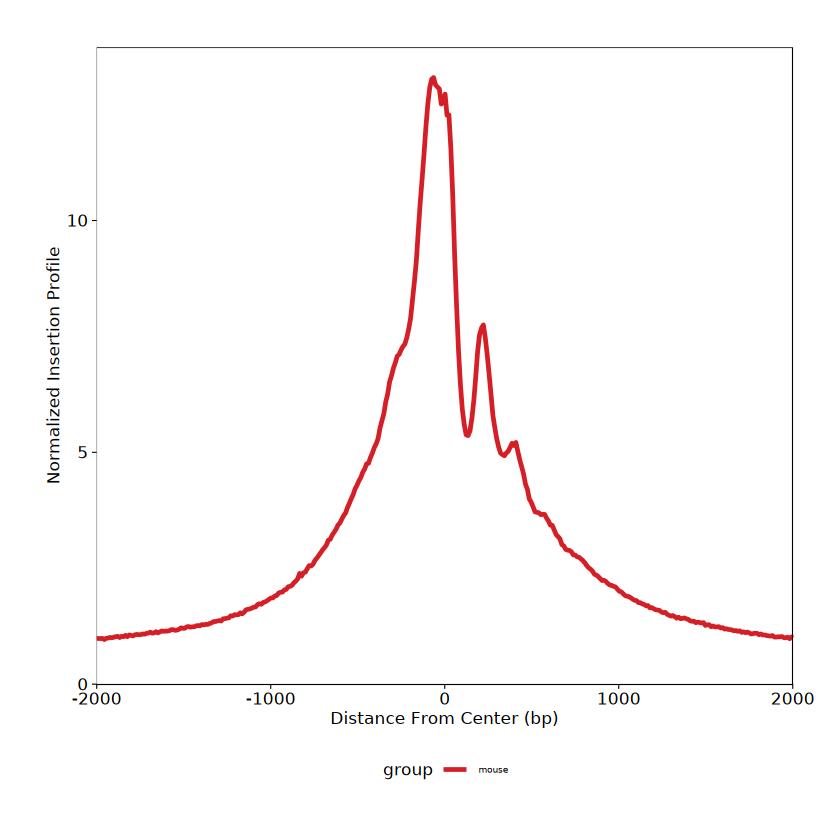

In [9]:
 plotTSSEnrichment(ArchRProj = proj)

In [12]:
## Save data
saveArchRProject(ArchRProj = proj, 
                 load = FALSE)

Saving ArchRProject...



In [13]:
head(proj@cellColData)

DataFrame with 6 rows and 11 columns
                       Sample TSSEnrichment ReadsInTSS ReadsInPromoter
                        <Rle>       <array>    <array>         <array>
mouse#GAGGCTCCAGAGTCGA  mouse        10.229      10326           33420
mouse#CTGTATTTCGTATAGC  mouse         9.869      10102           33263
mouse#TATCGAGGTAACGTAA  mouse        10.541      10338           33123
mouse#CGCAGGTAGAACGTCG  mouse         9.835       8950           29135
mouse#TTCTGTAGTATCCTTT  mouse         8.935       8194           27820
mouse#GCTTGCTGTTGTGAGG  mouse         11.22       9678           30277
                           PromoterRatio  PassQC  NucleosomeRatio nMultiFrags
                                 <array> <array>          <array>     <array>
mouse#GAGGCTCCAGAGTCGA 0.142007308574828       1 4.65829967301404       35866
mouse#CTGTATTTCGTATAGC 0.144250451013045       1 3.78366940502863       34032
mouse#TATCGAGGTAACGTAA 0.143647055762275       1 3.77898445595855       34521
mouse

In [14]:
write.csv(proj@cellColData, file = glue::glue("{out_dir}/cell_metadata.csv"), row.names = TRUE)